# 1. Giới thiệu hướng nghiên cứu

Notebook này xây dựng một pipeline nghiên cứu cho hướng:

**Hemorrhage-aware pretraining/localization từ Seg-CQ500/BHX -> fine-tuning segmentation trên PHE-SICH-CT-IDS**.

Mục tiêu là giữ notebook chạy lại được trên local, Kaggle hoặc Colab nếu chỉ chỉnh `CONFIG['project_root']`. Notebook luôn bắt đầu bằng scan dữ liệu thật trong hai thư mục `PHE-SICH-CT-IDS/` và `Seg-CQ500/`, sau đó mới tạo dataframe, visualization, DataLoader, model, training và đánh giá.

Lưu ý thực nghiệm:

- `PHE-SICH-CT-IDS` là dataset chính để fine-tune segmentation.
- `Seg-CQ500` trong workspace này có NIfTI volume `CT.nii` và mask `ICH_mask.nii.gz`, nên có thể dùng như segmentation pretraining nhẹ.
- Nếu một bản Seg-CQ500/BHX khác chỉ có bounding box, notebook sẽ thử parse bbox từ CSV/XML/JSON/TXT và tạo box-mask.
- Nếu không phát hiện được annotation phù hợp, notebook sẽ bỏ qua Stage A và chạy Stage B trực tiếp.

# 2. Cấu hình môi trường và đường dẫn

Chỉnh `project_root` nếu chạy notebook ngoài thư mục hiện tại. Các thư mục output chỉ được tạo khi chạy cell cấu hình.

In [1]:
from pathlib import Path

CONFIG = {
    'project_root': '.',
    'phe_dir': 'PHE-SICH-CT-IDS',
    'seg_cq500_dir': 'Seg-CQ500',
    'image_size': 512,
    'batch_size': 4,
    'num_workers': 0,
    'epochs_pretrain': 5,
    'epochs_finetune': 30,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'val_ratio': 0.15,
    'test_ratio': 0.15,
    'seed': 42,
    'use_amp': True,
    'use_seg_cq500_pretrain': True,
    'save_dir': 'outputs_phe_sich_seg_cq500',
}

# Cấu hình mở rộng, giữ mặc định nhẹ để dễ chạy thử.
CONFIG.update({
    'preferred_phe_source': 'auto',  # auto | 2d | nifti
    'max_slices_per_volume': None,   # đặt số nguyên nhỏ nếu muốn debug nhanh
    'positive_slice_only': False,
    'run_training': True,
    'run_full_ablation': False,
    'ablation_epochs': 3,
    'ct_window_center': 40,
    'ct_window_width': 80,
    'mask_threshold': 0,
    'num_visual_samples': 3,
})

PROJECT_ROOT = Path(CONFIG['project_root']).expanduser().resolve()
PHE_ROOT = PROJECT_ROOT / CONFIG['phe_dir']
SEG_CQ500_ROOT = PROJECT_ROOT / CONFIG['seg_cq500_dir']
SAVE_DIR = PROJECT_ROOT / CONFIG['save_dir']
CHECKPOINT_DIR = SAVE_DIR / 'checkpoints'
FIGURE_DIR = SAVE_DIR / 'figures'
LOG_DIR = SAVE_DIR / 'logs'
METRIC_DIR = SAVE_DIR / 'metrics'

for d in [SAVE_DIR, CHECKPOINT_DIR, FIGURE_DIR, LOG_DIR, METRIC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PHE_ROOT exists:', PHE_ROOT.exists(), PHE_ROOT)
print('SEG_CQ500_ROOT exists:', SEG_CQ500_ROOT.exists(), SEG_CQ500_ROOT)
print('SAVE_DIR:', SAVE_DIR)

PROJECT_ROOT: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao
PHE_ROOT exists: True D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS
SEG_CQ500_ROOT exists: True D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500
SAVE_DIR: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_phe_sich_seg_cq500


# 3. Import thư viện

Các thư viện bắt buộc: `numpy`, `pandas`, `matplotlib`, `PIL`, `torch`, `tqdm`.

Các thư viện tùy chọn:

- `nibabel`: đọc `.nii` / `.nii.gz`.
- `pydicom`: đọc DICOM.
- `timm`: EfficientNetV2-S encoder pretrained ImageNet.
- `scipy`: HD95/NSD.
- `sklearn`: split theo group thuận tiện hơn.

Nếu thiếu thư viện tùy chọn, notebook sẽ fallback hoặc in hướng dẫn cài đặt rõ ràng.

In [2]:
import ast
import json
import math
import os
import random
import re
import time
import warnings
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

try:
    import nibabel as nib
except ImportError:
    nib = None

try:
    import pydicom
except ImportError:
    pydicom = None

try:
    import timm
except ImportError:
    timm = None

try:
    from scipy.ndimage import binary_erosion, distance_transform_edt
except ImportError:
    binary_erosion = None
    distance_transform_edt = None

try:
    from sklearn.model_selection import GroupShuffleSplit
except ImportError:
    GroupShuffleSplit = None

warnings.filterwarnings('once')

print('torch:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('nibabel:', nib is not None)
print('pydicom:', pydicom is not None)
print('timm:', timm is not None)
print('scipy distance metrics:', distance_transform_edt is not None)

torch: 2.6.0+cu124
cuda available: True
nibabel: True
pydicom: False
timm: True
scipy distance metrics: True


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return torch.device('mps')
    return torch.device('cpu')


set_seed(CONFIG['seed'])
DEVICE = get_device()
print('DEVICE:', DEVICE)

DEVICE: cuda


# 4. Hàm tiện ích đọc dữ liệu y khoa

Phần này gom các hàm đọc ảnh 2D, NIfTI, DICOM, windowing CT và chuẩn hóa mask. Nếu ảnh là volume 3D, dataset sẽ lấy slice theo `slice_index` và hỗ trợ input 2.5D `[z-1, z, z+1]`.

In [4]:
IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.dcm', '.nii', '.gz'}
ANNOTATION_EXTS = {'.csv', '.json', '.xml', '.txt'}


def get_ext(path: Path) -> str:
    name = path.name.lower()
    if name.endswith('.nii.gz'):
        return '.nii.gz'
    return path.suffix.lower()


def is_nifti(path: Path) -> bool:
    return path.name.lower().endswith('.nii') or path.name.lower().endswith('.nii.gz')


def is_image_file(path: Path) -> bool:
    return get_ext(path) in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff', '.dcm', '.nii', '.nii.gz'}


def window_ct(img, center=40, width=80):
    img = np.asarray(img, dtype=np.float32)
    low = center - width / 2
    high = center + width / 2
    img = np.clip(img, low, high)
    return (img - low) / max(high - low, 1e-6)


def minmax_normalize(img):
    img = np.asarray(img, dtype=np.float32)
    lo, hi = np.nanmin(img), np.nanmax(img)
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return np.zeros_like(img, dtype=np.float32)
    return (img - lo) / (hi - lo)


def normalize_ct_or_image(img, center=None, width=None):
    img = np.asarray(img, dtype=np.float32)
    if np.nanmin(img) < -100 or np.nanmax(img) > 255:
        center = CONFIG['ct_window_center'] if center is None else center
        width = CONFIG['ct_window_width'] if width is None else width
        return window_ct(img, center=center, width=width)
    return minmax_normalize(img)


def read_2d_image(path: Path, grayscale=True):
    img = Image.open(path)
    img = img.convert('L' if grayscale else 'RGB')
    return np.asarray(img, dtype=np.float32)


def read_dicom(path: Path):
    if pydicom is None:
        raise ImportError('Thiếu pydicom. Cài bằng: pip install pydicom')
    ds = pydicom.dcmread(str(path))
    img = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, 'RescaleSlope', 1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    return img * slope + intercept


def read_nifti(path: Path):
    if nib is None:
        raise ImportError('Thiếu nibabel. Cài bằng: pip install nibabel')
    return np.asarray(nib.load(str(path)).get_fdata(), dtype=np.float32)


def pick_slice(volume, slice_index=None):
    arr = np.asarray(volume)
    if arr.ndim == 2:
        return arr
    if arr.ndim > 3:
        arr = np.squeeze(arr)
    if arr.ndim != 3:
        raise ValueError(f'Không hỗ trợ shape volume: {arr.shape}')
    axis = int(np.argmin(arr.shape)) if min(arr.shape) < 64 else 2
    n = arr.shape[axis]
    if slice_index is None:
        slice_index = n // 2
    slice_index = int(np.clip(slice_index, 0, n - 1))
    return np.take(arr, slice_index, axis=axis)


def slice_25d(volume, slice_index):
    arr = np.asarray(volume)
    if arr.ndim == 2:
        base = normalize_ct_or_image(arr)
        return np.stack([base, base, base], axis=0)
    if arr.ndim > 3:
        arr = np.squeeze(arr)
    axis = int(np.argmin(arr.shape)) if min(arr.shape) < 64 else 2
    n = arr.shape[axis]
    zs = [max(0, slice_index - 1), slice_index, min(n - 1, slice_index + 1)]
    slices = [normalize_ct_or_image(np.take(arr, z, axis=axis)) for z in zs]
    return np.stack(slices, axis=0)


def read_any_image(path: Path, slice_index=None, as_25d=False):
    ext = get_ext(path)
    if ext in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
        img = normalize_ct_or_image(read_2d_image(path, grayscale=True))
        return np.stack([img, img, img], axis=0) if as_25d else img
    if ext == '.dcm':
        img = normalize_ct_or_image(read_dicom(path))
        return np.stack([img, img, img], axis=0) if as_25d else img
    if is_nifti(path):
        vol = read_nifti(path)
        if as_25d:
            return slice_25d(vol, 0 if slice_index is None else int(slice_index))
        return normalize_ct_or_image(pick_slice(vol, slice_index=slice_index))
    raise ValueError(f'Không hỗ trợ file ảnh: {path}')


def read_mask(path: Path, slice_index=None):
    ext = get_ext(path)
    if ext in {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}:
        mask = read_2d_image(path, grayscale=True)
    elif ext == '.dcm':
        mask = read_dicom(path)
    elif is_nifti(path):
        mask = pick_slice(read_nifti(path), slice_index=slice_index)
    else:
        raise ValueError(f'Không hỗ trợ file mask: {path}')
    return (np.asarray(mask) > CONFIG['mask_threshold']).astype(np.float32)


def resize_tensor_image(image_chw, mask_hw=None, size=512):
    x = torch.from_numpy(np.asarray(image_chw, dtype=np.float32))
    if x.ndim == 2:
        x = x.unsqueeze(0).repeat(3, 1, 1)
    if x.ndim == 3 and x.shape[0] not in [1, 3]:
        x = x.permute(2, 0, 1)
    x = F.interpolate(x.unsqueeze(0), size=(size, size), mode='bilinear', align_corners=False).squeeze(0)
    if mask_hw is None:
        return x
    y = torch.from_numpy(np.asarray(mask_hw, dtype=np.float32)).unsqueeze(0).unsqueeze(0)
    y = F.interpolate(y, size=(size, size), mode='nearest').squeeze(0)
    return x, y

# 5. Khảo sát cấu trúc PHE-SICH-CT-IDS

Cell này scan dữ liệu thật, đếm file theo định dạng, in đường dẫn mẫu và kiểm tra nhanh các thư mục `set`, `label`, `annotation` nếu có.

In [5]:
def scan_files(root: Path, max_samples=8):
    root = Path(root)
    rows = []
    if not root.exists():
        print(f'Không tồn tại: {root}')
        return pd.DataFrame(columns=['path', 'relative_path', 'ext', 'size', 'role'])
    for path in root.rglob('*'):
        if not path.is_file():
            continue
        if '__MACOSX' in path.parts or path.name.startswith('._') or path.name == '.DS_Store':
            continue
        ext = get_ext(path)
        lower_parts = [p.lower() for p in path.parts]
        role = 'other'
        if any(p in {'label', 'labels', 'mask', 'masks'} or 'label' in p or 'mask' in p for p in lower_parts):
            role = 'mask_or_label'
        if any(p in {'annotation', 'annotations'} or 'annotation' in p for p in lower_parts) or path.suffix.lower() in ANNOTATION_EXTS:
            role = 'annotation'
        if any(p in {'set', 'image', 'images'} or p.startswith('image') for p in lower_parts) and role == 'other':
            role = 'image'
        rows.append({
            'path': path,
            'relative_path': path.relative_to(root),
            'ext': ext,
            'size': path.stat().st_size,
            'role': role,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        print(f'Không tìm thấy file trong {root}')
        return df
    print('Root:', root)
    print('Tổng số file:', len(df))
    display(df.groupby(['ext', 'role']).size().reset_index(name='count').sort_values(['ext', 'role']))
    print('Đường dẫn mẫu:')
    for p in df['relative_path'].head(max_samples):
        print(' -', p)
    return df


def summarize_tree(root: Path, max_depth=3):
    root = Path(root)
    rows = []
    if not root.exists():
        return pd.DataFrame()
    for path in root.rglob('*'):
        if '__MACOSX' in path.parts or path.name.startswith('._'):
            continue
        rel = path.relative_to(root)
        depth = len(rel.parts)
        if depth <= max_depth:
            rows.append({'depth': depth, 'type': 'dir' if path.is_dir() else 'file', 'relative_path': str(rel)})
    return pd.DataFrame(rows)


phe_scan_df = scan_files(PHE_ROOT)
phe_tree_df = summarize_tree(PHE_ROOT, max_depth=3)
display(phe_tree_df.head(80))

Root: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS
Tổng số file: 24880


,ext,role,count
0,.jpg,image,3511
1,.jpg,mask_or_label,3511
2,.nii.gz,image,120
3,.nii.gz,mask_or_label,120
4,.png,image,3511
5,.png,mask_or_label,7022
6,.xlsx,other,1
7,.xml,annotation,7084


Đường dẫn mẫu:
 - SubdatasetA_NIFIT\MedInfo.xlsx
 - SubdatasetA_NIFIT\NIFIT\label\0001.nii.gz
 - SubdatasetA_NIFIT\NIFIT\label\0002.nii.gz
 - SubdatasetA_NIFIT\NIFIT\label\0004.nii.gz
 - SubdatasetA_NIFIT\NIFIT\label\0005.nii.gz
 - SubdatasetA_NIFIT\NIFIT\label\0006.nii.gz
 - SubdatasetA_NIFIT\NIFIT\label\0008.nii.gz
 - SubdatasetA_NIFIT\NIFIT\label\0009.nii.gz


,depth,type,relative_path
0,1,dir,SubdatasetA_NIFIT
1,1,dir,SubdatasetB_JPG
2,1,dir,SubdatasetC_PNG
3,2,file,SubdatasetA_NIFIT\MedInfo.xlsx
4,2,dir,SubdatasetA_NIFIT\NIFIT
...,...,...,...
75,3,dir,SubdatasetB_JPG\annotation\annotation38
76,3,dir,SubdatasetB_JPG\annotation\annotation39
77,3,dir,SubdatasetB_JPG\annotation\annotation4
78,3,dir,SubdatasetB_JPG\annotation\annotation40


# 6. Khảo sát cấu trúc Seg-CQ500

Notebook scan `Seg-CQ500` và tự nhận diện hai khả năng:

- Có segmentation mask thật, ví dụ `ICH_mask.nii.gz`.
- Có bbox annotation từ CSV/XML/JSON/TXT, ví dụ theo định dạng BHX/VOC.

In [6]:
seg_scan_df = scan_files(SEG_CQ500_ROOT)
seg_tree_df = summarize_tree(SEG_CQ500_ROOT, max_depth=4)
display(seg_tree_df.head(100))

Root: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500
Tổng số file: 162


,ext,role,count
0,,other,2
1,.csv,annotation,1
2,.lock,other,1
3,.md,other,2
4,.nii,other,51
5,.nii.gz,mask_or_label,51
6,.nii.gz,other,51
7,.py,other,1
8,.toml,other,2


Đường dẫn mẫu:
 - Seg-CQ500\LICENSE
 - Seg-CQ500\README.md
 - Seg-CQ500\data\volumes\info.csv
 - Seg-CQ500\data\volumes\CQ500-CT-10\brain.nii.gz
 - Seg-CQ500\data\volumes\CQ500-CT-10\CT.nii
 - Seg-CQ500\data\volumes\CQ500-CT-10\ICH_mask.nii.gz
 - Seg-CQ500\data\volumes\CQ500-CT-108\brain.nii.gz
 - Seg-CQ500\data\volumes\CQ500-CT-108\CT.nii


,depth,type,relative_path
0,1,dir,Seg-CQ500
1,2,file,Seg-CQ500\.DS_Store
2,2,dir,Seg-CQ500\data
3,2,file,Seg-CQ500\LICENSE
4,2,file,Seg-CQ500\README.md
...,...,...,...
62,3,file,Seg-CQ500\tools\make_slice_dataset.py
63,3,file,Seg-CQ500\tools\poetry.lock
64,3,file,Seg-CQ500\tools\poetry.toml
65,3,file,Seg-CQ500\tools\pyproject.toml


# 7. Tạo dataframe quản lý dữ liệu

Các dataframe dùng chung cột chính:

- `image_path`: đường dẫn ảnh/volume.
- `mask_path`: đường dẫn mask nếu có.
- `bbox`: danh sách bbox nếu có, dạng `[xmin, ymin, xmax, ymax]`.
- `patient_id`: id suy ra từ filename/path để split theo bệnh nhân.
- `source`: nguồn dữ liệu.
- `sample_type`: `image2d`, `nifti_volume`, hoặc `nifti_slice`.

In [7]:
def strip_nii_suffix(name: str) -> str:
    return re.sub(r'\.nii(\.gz)?$', '', name, flags=re.IGNORECASE)


def parse_patient_id(path):
    s = str(path).replace('\\', '/')
    m = re.search(r'(CQ500-CT-\d+)', s, flags=re.IGNORECASE)
    if m:
        return m.group(1)
    name = Path(s).stem
    m = re.search(r'(\d{3,5})(?:[_-]\d+)?', name)
    if m:
        return m.group(1).lstrip('0') or m.group(1)
    parts = Path(s).parts
    for part in reversed(parts):
        m = re.search(r'(image|label)(\d+)', part, flags=re.IGNORECASE)
        if m:
            return m.group(2)
    return None


def find_phe_nifti_pairs(root: Path):
    rows = []
    if not root.exists():
        return pd.DataFrame(rows)
    set_files = [p for p in root.rglob('*') if p.is_file() and is_nifti(p) and any(part.lower() == 'set' for part in p.parts)]
    label_files = [p for p in root.rglob('*') if p.is_file() and is_nifti(p) and any(part.lower() == 'label' for part in p.parts)]
    labels = {strip_nii_suffix(p.name): p for p in label_files}
    for img in set_files:
        key = strip_nii_suffix(img.name)
        mask = labels.get(key)
        rows.append({
            'image_path': img,
            'mask_path': mask,
            'bbox': None,
            'patient_id': parse_patient_id(img),
            'source': 'PHE-SICH-CT-IDS',
            'sample_type': 'nifti_volume',
            'modality': 'nifti',
        })
    return pd.DataFrame(rows)


def build_mask_index(label_root: Path):
    mask_index = defaultdict(list)
    if not label_root.exists():
        return mask_index
    for p in label_root.rglob('*'):
        if not p.is_file() or not is_image_file(p):
            continue
        if is_nifti(p) or get_ext(p) == '.dcm':
            continue
        mask_index[p.stem].append(p)
    return mask_index


def choose_mask(mask_candidates):
    if not mask_candidates:
        return None
    png = [p for p in mask_candidates if p.suffix.lower() == '.png']
    return sorted(png or mask_candidates, key=lambda x: str(x))[0]


def parse_voc_xml(xml_path: Path):
    boxes = []
    try:
        root = ET.parse(xml_path).getroot()
        for obj in root.findall('object'):
            bnd = obj.find('bndbox')
            if bnd is None:
                continue
            xmin = float(bnd.findtext('xmin', '0'))
            ymin = float(bnd.findtext('ymin', '0'))
            xmax = float(bnd.findtext('xmax', '0'))
            ymax = float(bnd.findtext('ymax', '0'))
            if xmax > xmin and ymax > ymin:
                boxes.append([xmin, ymin, xmax, ymax])
    except Exception as e:
        warnings.warn(f'Không parse được XML {xml_path}: {e}')
    return boxes


def build_xml_bbox_index(annotation_root: Path):
    bbox_index = defaultdict(list)
    if not annotation_root.exists():
        return bbox_index
    for xml_path in annotation_root.rglob('*.xml'):
        boxes = parse_voc_xml(xml_path)
        if boxes:
            bbox_index[xml_path.stem].extend(boxes)
    return bbox_index


def find_phe_2d_pairs(root: Path):
    rows = []
    if not root.exists():
        return pd.DataFrame(rows)
    for subset in [p for p in root.iterdir() if p.is_dir()]:
        set_root = subset / 'set'
        label_root = subset / 'label'
        annotation_root = subset / 'annotation'
        if not set_root.exists():
            continue
        mask_index = build_mask_index(label_root)
        bbox_index = build_xml_bbox_index(annotation_root)
        for img in set_root.rglob('*'):
            if not img.is_file() or not is_image_file(img) or is_nifti(img) or get_ext(img) == '.dcm':
                continue
            mask = choose_mask(mask_index.get(img.stem, []))
            boxes = bbox_index.get(img.stem, [])
            rows.append({
                'image_path': img,
                'mask_path': mask,
                'bbox': boxes if boxes else None,
                'patient_id': parse_patient_id(img),
                'source': 'PHE-SICH-CT-IDS',
                'sample_type': 'image2d',
                'modality': get_ext(img).replace('.', ''),
            })
    return pd.DataFrame(rows)


phe_nifti_df = find_phe_nifti_pairs(PHE_ROOT)
phe_2d_df = find_phe_2d_pairs(PHE_ROOT)

print('PHE NIfTI volume pairs:', len(phe_nifti_df))
print('PHE 2D image rows:', len(phe_2d_df))
if not phe_nifti_df.empty:
    display(phe_nifti_df.head())
if not phe_2d_df.empty:
    display(phe_2d_df.head())

PHE NIfTI volume pairs: 120
PHE 2D image rows: 7022


,image_path,mask_path,bbox,patient_id,source,sample_type,modality
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,nifti_volume,nifti
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,2,PHE-SICH-CT-IDS,nifti_volume,nifti
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,4,PHE-SICH-CT-IDS,nifti_volume,nifti
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,5,PHE-SICH-CT-IDS,nifti_volume,nifti
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,6,PHE-SICH-CT-IDS,nifti_volume,nifti


,image_path,mask_path,bbox,patient_id,source,sample_type,modality
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg


In [8]:
def find_seg_cq500_volume_pairs(root: Path):
    rows = []
    candidate_roots = [root / 'Seg-CQ500' / 'data' / 'volumes', root / 'data' / 'volumes']
    volumes_root = next((p for p in candidate_roots if p.exists()), None)
    if volumes_root is None:
        return pd.DataFrame(rows)
    info_csv = volumes_root / 'info.csv'
    if info_csv.exists():
        info = pd.read_csv(info_csv)
        for _, r in info.iterrows():
            ct = volumes_root / str(r.get('CT_fn', ''))
            mask = volumes_root / str(r.get('mask_fn', ''))
            if ct.exists() and mask.exists():
                rows.append({
                    'image_path': ct,
                    'mask_path': mask,
                    'bbox': None,
                    'patient_id': str(r.get('name', parse_patient_id(ct))),
                    'source': 'Seg-CQ500',
                    'sample_type': 'nifti_volume',
                    'modality': 'nifti',
                })
    if not rows:
        for case_dir in volumes_root.iterdir():
            if not case_dir.is_dir():
                continue
            ct = case_dir / 'CT.nii'
            mask = case_dir / 'ICH_mask.nii.gz'
            if ct.exists() and mask.exists():
                rows.append({
                    'image_path': ct,
                    'mask_path': mask,
                    'bbox': None,
                    'patient_id': parse_patient_id(case_dir),
                    'source': 'Seg-CQ500',
                    'sample_type': 'nifti_volume',
                    'modality': 'nifti',
                })
    return pd.DataFrame(rows)


def parse_bhx_data_cell(value):
    if pd.isna(value):
        return None
    if isinstance(value, dict):
        d = value
    else:
        try:
            d = ast.literal_eval(str(value))
        except Exception:
            return None
    if {'x', 'y', 'width', 'height'}.issubset(d.keys()):
        x, y, w, h = float(d['x']), float(d['y']), float(d['width']), float(d['height'])
        return [x, y, x + w, y + h]
    return None


def parse_bbox_from_csv(path: Path):
    rows = []
    try:
        df = pd.read_csv(path)
    except Exception:
        return rows
    cols = {c.lower(): c for c in df.columns}
    for _, r in df.iterrows():
        box = None
        if 'data' in cols:
            box = parse_bhx_data_cell(r[cols['data']])
        elif {'xmin', 'ymin', 'xmax', 'ymax'}.issubset(cols):
            box = [float(r[cols['xmin']]), float(r[cols['ymin']]), float(r[cols['xmax']]), float(r[cols['ymax']])]
        elif {'x', 'y', 'w', 'h'}.issubset(cols):
            x, y, w, h = float(r[cols['x']]), float(r[cols['y']]), float(r[cols['w']]), float(r[cols['h']])
            box = [x, y, x + w, y + h]
        elif {'x', 'y', 'width', 'height'}.issubset(cols):
            x, y, w, h = float(r[cols['x']]), float(r[cols['y']]), float(r[cols['width']]), float(r[cols['height']])
            box = [x, y, x + w, y + h]
        if box is None:
            continue
        image_id = None
        for key in ['SOPInstanceUID', 'filename', 'file', 'image', 'image_path']:
            if key in df.columns:
                image_id = str(r[key])
                break
        rows.append({'annotation_path': path, 'image_id': image_id, 'bbox': box, 'label': r.get('labelName', r.get('label', None))})
    return rows


def scan_bbox_annotations(root: Path):
    bbox_rows = []
    if not root.exists():
        return pd.DataFrame(bbox_rows)
    for path in root.rglob('*'):
        if not path.is_file() or '__MACOSX' in path.parts or path.name.startswith('._'):
            continue
        if path.suffix.lower() == '.xml':
            for box in parse_voc_xml(path):
                bbox_rows.append({'annotation_path': path, 'image_id': path.stem, 'bbox': box, 'label': None})
        elif path.suffix.lower() == '.csv':
            bbox_rows.extend(parse_bbox_from_csv(path))
    return pd.DataFrame(bbox_rows)


seg_volume_df = find_seg_cq500_volume_pairs(SEG_CQ500_ROOT)
seg_bbox_df = scan_bbox_annotations(SEG_CQ500_ROOT)
print('Seg-CQ500 volume-mask pairs:', len(seg_volume_df))
print('Seg-CQ500/BHX bbox annotations parsed:', len(seg_bbox_df))
if not seg_volume_df.empty:
    display(seg_volume_df.head())
if not seg_bbox_df.empty:
    display(seg_bbox_df.head())

Seg-CQ500 volume-mask pairs: 51
Seg-CQ500/BHX bbox annotations parsed: 0


,image_path,mask_path,bbox,patient_id,source,sample_type,modality
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,None,CQ500-CT-159,Seg-CQ500,nifti_volume,nifti
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,None,CQ500-CT-35,Seg-CQ500,nifti_volume,nifti
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,None,CQ500-CT-61,Seg-CQ500,nifti_volume,nifti
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,None,CQ500-CT-95,Seg-CQ500,nifti_volume,nifti
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,None,CQ500-CT-57,Seg-CQ500,nifti_volume,nifti


In [9]:
def inspect_pair_shapes(df, n=8):
    rows = []
    for _, r in df.dropna(subset=['image_path', 'mask_path']).head(n).iterrows():
        img_path = Path(r['image_path'])
        mask_path = Path(r['mask_path'])
        try:
            if is_nifti(img_path):
                if nib is None:
                    rows.append({'image_path': img_path, 'status': 'skip: thiếu nibabel'})
                    continue
                img_shape = nib.load(str(img_path)).shape
                mask_shape = nib.load(str(mask_path)).shape
            else:
                img_shape = Image.open(img_path).size[::-1]
                mask_shape = Image.open(mask_path).size[::-1]
            rows.append({'image_path': img_path, 'mask_path': mask_path, 'image_shape': img_shape, 'mask_shape': mask_shape, 'match': img_shape[:2] == mask_shape[:2]})
        except Exception as e:
            rows.append({'image_path': img_path, 'mask_path': mask_path, 'status': str(e)})
    return pd.DataFrame(rows)


print('Kiểm tra shape PHE 2D:')
display(inspect_pair_shapes(phe_2d_df, n=8))
print('Kiểm tra shape PHE NIfTI:')
display(inspect_pair_shapes(phe_nifti_df, n=8))
print('Kiểm tra shape Seg-CQ500:')
display(inspect_pair_shapes(seg_volume_df, n=5))


def choose_phe_dataframe():
    mode = CONFIG['preferred_phe_source']
    if mode == '2d':
        return phe_2d_df.copy()
    if mode == 'nifti':
        return phe_nifti_df.copy()
    if not phe_2d_df.empty:
        return phe_2d_df.copy()
    return phe_nifti_df.copy()


phe_base_df = choose_phe_dataframe()
print('PHE dataframe được chọn:', len(phe_base_df), 'rows')
display(phe_base_df['sample_type'].value_counts(dropna=False).to_frame('count') if not phe_base_df.empty else pd.DataFrame())

Kiểm tra shape PHE 2D:


C:\Users\AD\AppData\Local\Temp\ipykernel_29188\4033181631.py:14: ResourceWarning: unclosed file <_io.BufferedReader name='D:\\Thuy_Loi\\Nam_3\\CT_xuathuyetnao\\PHE-SICH-CT-IDS\\SubdatasetB_JPG\\set\\image1\\0001_00.jpg'>
  img_shape = Image.open(img_path).size[::-1]
C:\Users\AD\AppData\Local\Temp\ipykernel_29188\4033181631.py:15: ResourceWarning: unclosed file <_io.BufferedReader name='D:\\Thuy_Loi\\Nam_3\\CT_xuathuyetnao\\PHE-SICH-CT-IDS\\SubdatasetB_JPG\\label\\label1\\0001_00.png'>
  mask_shape = Image.open(mask_path).size[::-1]
C:\Users\AD\AppData\Local\Temp\ipykernel_29188\4033181631.py:14: ResourceWarning: unclosed file <_io.BufferedReader name='D:\\Thuy_Loi\\Nam_3\\CT_xuathuyetnao\\PHE-SICH-CT-IDS\\SubdatasetB_JPG\\set\\image1\\0001_01.jpg'>
  img_shape = Image.open(img_path).size[::-1]
C:\Users\AD\AppData\Local\Temp\ipykernel_29188\4033181631.py:15: ResourceWarning: unclosed file <_io.BufferedReader name='D:\\Thuy_Loi\\Nam_3\\CT_xuathuyetnao\\PHE-SICH-CT-IDS\\SubdatasetB_JPG\\l

,image_path,mask_path,image_shape,mask_shape,match
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
5,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
6,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True
7,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512)","(512, 512)",True


Kiểm tra shape PHE NIfTI:


,image_path,mask_path,image_shape,mask_shape,match
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
5,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
6,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 32)","(512, 512, 32)",True
7,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,"(512, 512, 30)","(512, 512, 30)",True


Kiểm tra shape Seg-CQ500:


,image_path,mask_path,image_shape,mask_shape,match
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,"(512, 512, 256)","(512, 512, 256)",True
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,"(512, 512, 288)","(512, 512, 288)",True
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,"(512, 512, 58)","(512, 512, 58)",True
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,"(512, 512, 233)","(512, 512, 233)",True
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\Seg-CQ500\Se...,"(512, 512, 256)","(512, 512, 256)",True


PHE dataframe được chọn: 7022 rows


,count
sample_type,
image2d,7022


# 8. Visualization ảnh, mask, bounding box

Cell này hiển thị ảnh, mask, overlay và bbox nếu có. Nếu thiếu mask/bbox thì vẫn chạy và ghi chú rõ.

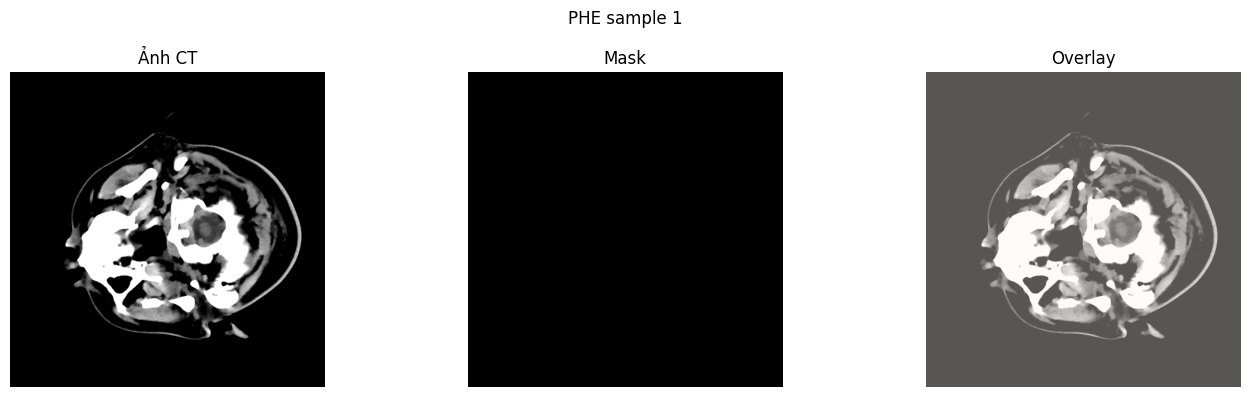

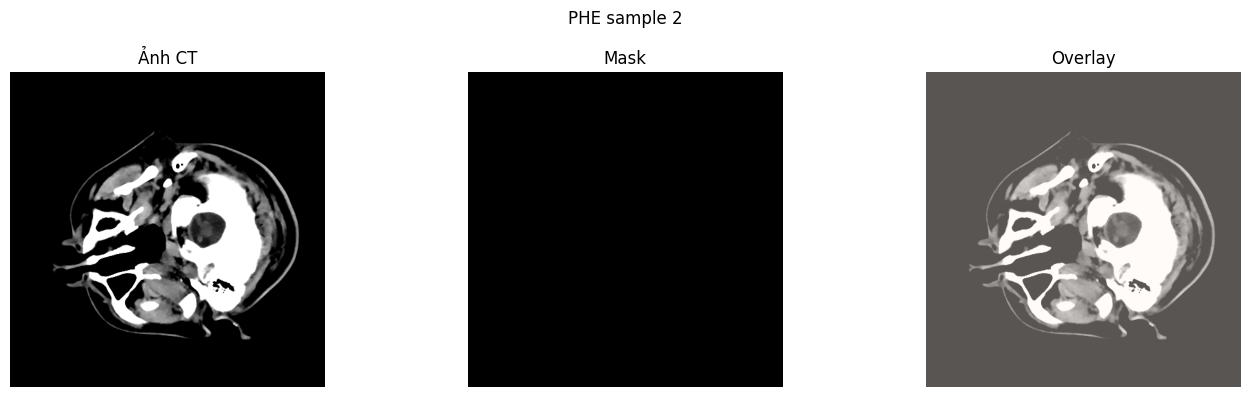

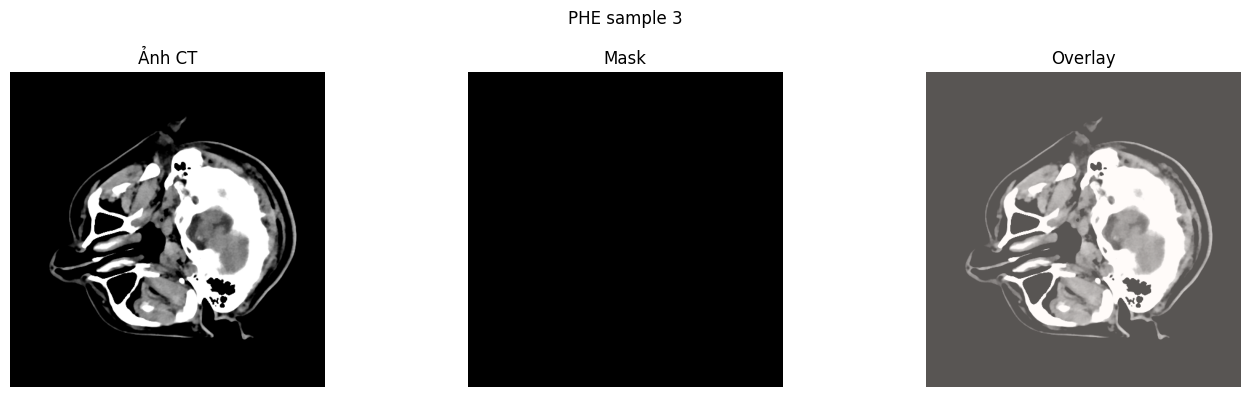

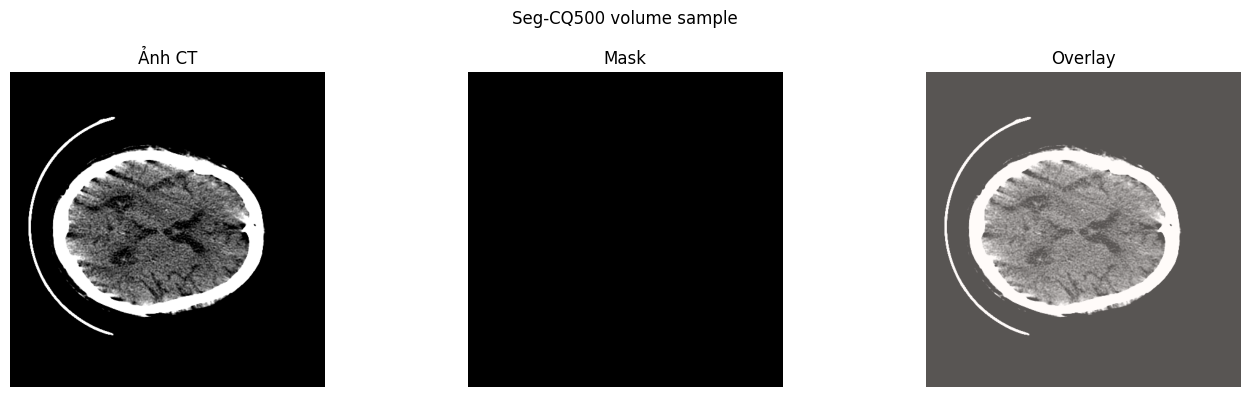

In [10]:
def draw_boxes_on_axis(ax, boxes, color='yellow'):
    if not boxes:
        return
    for box in boxes:
        xmin, ymin, xmax, ymax = box
        rect = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, edgecolor=color, linewidth=2)
        ax.add_patch(rect)


def show_sample(row, title=None, save_path=None):
    img_path = Path(row['image_path'])
    mask_path = row.get('mask_path', None)
    slice_index = row.get('slice_index', None)
    try:
        image = read_any_image(img_path, slice_index=slice_index, as_25d=False)
    except Exception as e:
        print('Không đọc được ảnh:', img_path, e)
        return
    mask = None
    if mask_path is not None and pd.notna(mask_path):
        try:
            mask = read_mask(Path(mask_path), slice_index=slice_index)
        except Exception as e:
            print('Không đọc được mask:', mask_path, e)
    boxes = row.get('bbox', None)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Ảnh CT')
    draw_boxes_on_axis(axes[0], boxes)
    if mask is not None:
        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title('Mask')
        axes[2].imshow(image, cmap='gray')
        axes[2].imshow(mask, cmap='Reds', alpha=0.35)
        axes[2].set_title('Overlay')
    else:
        axes[1].axis('off')
        axes[1].set_title('Không có mask')
        axes[2].imshow(image, cmap='gray')
        draw_boxes_on_axis(axes[2], boxes)
        axes[2].set_title('BBox nếu có')
    for ax in axes:
        ax.axis('off')
    fig.suptitle(title or str(img_path.name))
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


if not phe_base_df.empty:
    sample_rows = phe_base_df.dropna(subset=['mask_path']).head(CONFIG['num_visual_samples'])
    for i, (_, row) in enumerate(sample_rows.iterrows()):
        show_sample(row, title=f'PHE sample {i + 1}', save_path=FIGURE_DIR / 'sample_visualization.png' if i == 0 else None)
else:
    print('Không có PHE dataframe để visualization.')

if not seg_volume_df.empty:
    show_sample(seg_volume_df.iloc[0], title='Seg-CQ500 volume sample')
elif not seg_bbox_df.empty:
    print('Phát hiện bbox annotation nhưng chưa mapping được sang ảnh cụ thể trong cell này.')
else:
    print('Không phát hiện annotation phù hợp trong Seg-CQ500, bỏ qua visualization bbox/pretraining.')

# 9. Dataset và DataLoader

Phần này biến volume NIfTI thành slice 2D/2.5D, tách train/val/test và tạo `Dataset` PyTorch.

In [11]:
def volume_slice_axis(shape):
    return int(np.argmin(shape)) if min(shape) < 64 else 2


def positive_slices_from_mask(mask_path: Path):
    mask = read_nifti(mask_path)
    if mask.ndim > 3:
        mask = np.squeeze(mask)
    axis = volume_slice_axis(mask.shape)
    sums = np.sum(mask > CONFIG['mask_threshold'], axis=tuple(i for i in range(mask.ndim) if i != axis))
    return np.where(sums > 0)[0].astype(int).tolist(), int(mask.shape[axis])


def expand_volume_dataframe(df: pd.DataFrame, source_name='volume'):
    rows = []
    if df.empty:
        return pd.DataFrame(rows)
    if nib is None:
        print('Thiếu nibabel nên không thể expand NIfTI. Cài bằng: pip install nibabel')
        return pd.DataFrame(rows)
    for _, r in tqdm(df.iterrows(), total=len(df), desc=f'Expand {source_name}'):
        img_path = Path(r['image_path'])
        mask_path = Path(r['mask_path']) if pd.notna(r.get('mask_path', None)) else None
        try:
            if mask_path and mask_path.exists():
                pos, n_slices = positive_slices_from_mask(mask_path)
            else:
                shape = nib.load(str(img_path)).shape
                axis = volume_slice_axis(shape)
                n_slices = int(shape[axis])
                pos = []
        except Exception as e:
            warnings.warn(f'Bỏ qua volume {img_path}: {e}')
            continue
        selected = pos if CONFIG['positive_slice_only'] and pos else list(range(n_slices))
        if CONFIG['max_slices_per_volume'] is not None and len(selected) > CONFIG['max_slices_per_volume']:
            rng = np.random.default_rng(CONFIG['seed'])
            keep_pos = [z for z in selected if z in set(pos)]
            rest = [z for z in selected if z not in set(pos)]
            budget = int(CONFIG['max_slices_per_volume'])
            sampled = keep_pos[:budget]
            if len(sampled) < budget and rest:
                sampled += rng.choice(rest, size=min(budget - len(sampled), len(rest)), replace=False).astype(int).tolist()
            selected = sorted(set(sampled))
        for z in selected:
            item = r.to_dict()
            item.update({'slice_index': int(z), 'sample_type': 'nifti_slice', 'has_positive_mask': int(z in set(pos))})
            rows.append(item)
    return pd.DataFrame(rows)


def prepare_training_rows(base_df: pd.DataFrame, name='PHE'):
    if base_df.empty:
        return base_df
    parts = []
    vol_df = base_df[base_df['sample_type'].eq('nifti_volume')].copy() if 'sample_type' in base_df else pd.DataFrame()
    img_df = base_df[base_df['sample_type'].eq('image2d')].copy() if 'sample_type' in base_df else pd.DataFrame()
    if not vol_df.empty:
        parts.append(expand_volume_dataframe(vol_df, source_name=name))
    if not img_df.empty:
        img_df = img_df.dropna(subset=['mask_path']).copy()
        img_df['slice_index'] = None
        img_df['has_positive_mask'] = np.nan
        parts.append(img_df)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True).dropna(subset=['image_path', 'mask_path']).reset_index(drop=True)


phe_trainable_df = prepare_training_rows(phe_base_df, name='PHE')
seg_trainable_df = prepare_training_rows(seg_volume_df, name='Seg-CQ500') if not seg_volume_df.empty else pd.DataFrame()
print('PHE trainable rows:', len(phe_trainable_df))
print('Seg-CQ500 trainable rows:', len(seg_trainable_df))
display(phe_trainable_df.head())

Expand Seg-CQ500:   0%|          | 0/51 [00:00<?, ?it/s]

PHE trainable rows: 6957
Seg-CQ500 trainable rows: 11175


,image_path,mask_path,bbox,patient_id,source,sample_type,modality,slice_index,has_positive_mask
0,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg,None,NaN
1,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg,None,NaN
2,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg,None,NaN
3,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg,None,NaN
4,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-...,None,1,PHE-SICH-CT-IDS,image2d,jpg,None,NaN


In [12]:
def safe_group_split(df, val_ratio=0.15, test_ratio=0.15, seed=42):
    if df.empty:
        return df.copy(), df.copy(), df.copy()
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    groups = df['patient_id'].fillna('missing').astype(str)
    can_group = groups.nunique() >= 3 and not groups.eq('missing').all()
    if not can_group:
        print('Warning: Không tìm thấy patient id rõ ràng, đang split theo image-level. Cần kiểm tra lại để tránh data leakage.')
        n = len(df)
        n_test = max(1, int(round(n * test_ratio))) if n >= 3 and test_ratio > 0 else 0
        n_val = max(1, int(round(n * val_ratio))) if n - n_test >= 3 and val_ratio > 0 else 0
        test_df = df.iloc[:n_test]
        val_df = df.iloc[n_test:n_test + n_val]
        train_df = df.iloc[n_test + n_val:]
        return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)
    if GroupShuffleSplit is not None and test_ratio > 0:
        gss1 = GroupShuffleSplit(n_splits=1, test_size=test_ratio, random_state=seed)
        train_val_idx, test_idx = next(gss1.split(df, groups=groups))
        train_val = df.iloc[train_val_idx].reset_index(drop=True)
        test = df.iloc[test_idx].reset_index(drop=True)
        tv_groups = train_val['patient_id'].fillna('missing').astype(str)
        val_size = val_ratio / max(1e-6, 1 - test_ratio)
        gss2 = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=seed)
        train_idx, val_idx = next(gss2.split(train_val, groups=tv_groups))
        return train_val.iloc[train_idx].reset_index(drop=True), train_val.iloc[val_idx].reset_index(drop=True), test
    unique_groups = np.array(sorted(groups.unique()))
    rng = np.random.default_rng(seed)
    rng.shuffle(unique_groups)
    n_test = max(1, int(len(unique_groups) * test_ratio)) if test_ratio > 0 else 0
    n_val = max(1, int(len(unique_groups) * val_ratio)) if val_ratio > 0 else 0
    test_g = set(unique_groups[:n_test])
    val_g = set(unique_groups[n_test:n_test + n_val])
    train_g = set(unique_groups[n_test + n_val:])
    return df[groups.isin(train_g)].reset_index(drop=True), df[groups.isin(val_g)].reset_index(drop=True), df[groups.isin(test_g)].reset_index(drop=True)


train_df, val_df, test_df = safe_group_split(phe_trainable_df, CONFIG['val_ratio'], CONFIG['test_ratio'], CONFIG['seed'])
print('PHE split sizes:', len(train_df), len(val_df), len(test_df))


def patient_set(df):
    return set(df['patient_id'].dropna().astype(str).tolist()) if not df.empty else set()


print('train/val overlap:', len(patient_set(train_df) & patient_set(val_df)))
print('train/test overlap:', len(patient_set(train_df) & patient_set(test_df)))
print('val/test overlap:', len(patient_set(val_df) & patient_set(test_df)))

PHE split sizes: 4943 988 1026
train/val overlap: 0
train/test overlap: 0
val/test overlap: 0


In [13]:
class HemorrhageSegmentationDataset(Dataset):
    def __init__(self, df, image_size=512, training=False):
        self.df = df.reset_index(drop=True).copy()
        self.image_size = image_size
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = Path(row['image_path'])
        mask_path = Path(row['mask_path'])
        slice_index = row.get('slice_index', None)
        if pd.isna(slice_index):
            slice_index = None
        else:
            slice_index = int(slice_index)
        image = read_any_image(image_path, slice_index=slice_index, as_25d=True)
        mask = read_mask(mask_path, slice_index=slice_index)
        x, y = resize_tensor_image(image, mask, size=self.image_size)
        if self.training and random.random() < 0.5:
            x = torch.flip(x, dims=[2])
            y = torch.flip(y, dims=[2])
        return {
            'image': x.float(),
            'mask': y.float(),
            'image_path': str(image_path),
            'mask_path': str(mask_path),
            'slice_index': -1 if slice_index is None else slice_index,
        }


def make_loader(df, training=False, shuffle=None):
    if df.empty:
        return None
    ds = HemorrhageSegmentationDataset(df, image_size=CONFIG['image_size'], training=training)
    if shuffle is None:
        shuffle = training
    return DataLoader(
        ds,
        batch_size=CONFIG['batch_size'],
        shuffle=shuffle,
        num_workers=CONFIG['num_workers'],
        pin_memory=torch.cuda.is_available(),
        drop_last=False,
    )


train_loader = make_loader(train_df, training=True)
val_loader = make_loader(val_df, training=False)
test_loader = make_loader(test_df, training=False)

if train_loader is not None:
    batch = next(iter(train_loader))
    print('Batch image:', batch['image'].shape, 'Batch mask:', batch['mask'].shape)

Batch image: torch.Size([4, 3, 512, 512]) Batch mask: torch.Size([4, 1, 512, 512])


# 10. Model EfficientNetV2-S + Decoder

Nếu có `timm`, model dùng `tf_efficientnetv2_s.in21k` hoặc fallback `tf_efficientnetv2_s`. Nếu không có `timm`, notebook dùng encoder CNN nhẹ để vẫn chạy end-to-end.

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleEncoder(nn.Module):
    def __init__(self, in_ch=3, channels=(32, 64, 128, 256)):
        super().__init__()
        self.stages = nn.ModuleList()
        prev = in_ch
        for ch in channels:
            self.stages.append(nn.Sequential(ConvBlock(prev, ch), nn.MaxPool2d(2)))
            prev = ch
        self.channels = list(channels)

    def forward(self, x):
        feats = []
        for stage in self.stages:
            conv = stage[0]
            pool = stage[1]
            x = conv(x)
            feats.append(x)
            x = pool(x)
        return feats


class FPNDecoder(nn.Module):
    def __init__(self, encoder_channels, decoder_ch=128, out_ch=1):
        super().__init__()
        self.lateral = nn.ModuleList([nn.Conv2d(ch, decoder_ch, 1) for ch in encoder_channels])
        self.fuse = ConvBlock(decoder_ch * len(encoder_channels), decoder_ch)
        self.head = nn.Conv2d(decoder_ch, out_ch, 1)

    def forward(self, feats, input_size):
        target_size = feats[0].shape[-2:]
        ups = []
        for f, lat in zip(feats, self.lateral):
            u = lat(f)
            if u.shape[-2:] != target_size:
                u = F.interpolate(u, size=target_size, mode='bilinear', align_corners=False)
            ups.append(u)
        x = self.fuse(torch.cat(ups, dim=1))
        x = self.head(x)
        if x.shape[-2:] != input_size:
            x = F.interpolate(x, size=input_size, mode='bilinear', align_corners=False)
        return x


class EfficientNetV2SDecoder(nn.Module):
    def __init__(self, out_ch=1, pretrained=True):
        super().__init__()
        self.uses_timm = timm is not None
        if self.uses_timm:
            model_name_candidates = ['tf_efficientnetv2_s.in21k', 'tf_efficientnetv2_s', 'efficientnetv2_s']
            last_error = None
            for model_name in model_name_candidates:
                try:
                    self.encoder = timm.create_model(model_name, pretrained=pretrained, features_only=True, in_chans=3)
                    self.encoder_name = model_name
                    break
                except Exception as e:
                    last_error = e
                    self.encoder = None
            if self.encoder is None:
                warnings.warn(f'Không tạo được EfficientNetV2-S từ timm: {last_error}. Dùng SimpleEncoder.')
                self.uses_timm = False
        if self.uses_timm:
            channels = self.encoder.feature_info.channels()
        else:
            self.encoder = SimpleEncoder(in_ch=3)
            self.encoder_name = 'simple_cnn'
            channels = self.encoder.channels
        self.decoder = FPNDecoder(channels, decoder_ch=128, out_ch=out_ch)

    def forward(self, x):
        input_size = x.shape[-2:]
        feats = self.encoder(x)
        return self.decoder(feats, input_size)


def build_model(pretrained=True):
    model = EfficientNetV2SDecoder(out_ch=1, pretrained=pretrained)
    print('Encoder:', model.encoder_name)
    return model


model = build_model(pretrained=True).to(DEVICE)
with torch.no_grad():
    dummy = torch.zeros(1, 3, CONFIG['image_size'], CONFIG['image_size'], device=DEVICE)
    out = model(dummy)
print('Model output:', out.shape)

model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x265a3ce07c0>
  self._event_pipes[threading.current_thread()] = event_pipe
c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x265a3ce16a0>
  self._event_pipes[threading.current_thread()] = event_pipe
c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x265a3ce09f0>
  self._event_pipes[threading.current_thread()] = event_pipe
c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x265a4355390>
  self._event_pipes[threading.current_thread()] = event_pipe
c:\Users\AD\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggin

Encoder: tf_efficientnetv2_s.in21k
Model output: torch.Size([1, 1, 512, 512])


# 11. Loss function và metrics

Loss mặc định là `BCEWithLogitsLoss + DiceLoss` cho binary segmentation. Metrics gồm Dice, IoU, Precision, Recall; HD95 và NSD là tùy chọn nếu có `scipy`.

In [15]:
def dice_loss_from_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    targets = targets.float()
    dims = tuple(range(1, probs.ndim))
    inter = torch.sum(probs * targets, dims)
    denom = torch.sum(probs, dims) + torch.sum(targets, dims)
    dice = (2 * inter + eps) / (denom + eps)
    return 1 - dice.mean()


def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets.float())
    dloss = dice_loss_from_logits(logits, targets)
    return bce + dloss


def surface_distances(mask_a, mask_b):
    if distance_transform_edt is None or binary_erosion is None:
        return None
    mask_a = mask_a.astype(bool)
    mask_b = mask_b.astype(bool)
    if not mask_a.any() and not mask_b.any():
        return np.array([0.0])
    if not mask_a.any() or not mask_b.any():
        return np.array([np.inf])
    surf_a = mask_a ^ binary_erosion(mask_a)
    surf_b = mask_b ^ binary_erosion(mask_b)
    dt_b = distance_transform_edt(~surf_b)
    dt_a = distance_transform_edt(~surf_a)
    return np.concatenate([dt_b[surf_a], dt_a[surf_b]]).astype(np.float32)


def hd95_np(pred, target):
    d = surface_distances(pred, target)
    if d is None:
        return np.nan
    if np.isinf(d).any():
        return np.inf
    return float(np.percentile(d, 95))


def nsd_np(pred, target, tolerance=2.0):
    d = surface_distances(pred, target)
    if d is None:
        return np.nan
    if np.isinf(d).any():
        return 0.0
    return float((d <= tolerance).mean())


def compute_metrics(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits).detach().cpu().numpy()
    targets_np = targets.detach().cpu().numpy()
    preds = probs >= threshold
    targets_bin = targets_np >= 0.5
    eps = 1e-6
    metrics = []
    for pred, target in zip(preds, targets_bin):
        pred = np.squeeze(pred).astype(bool)
        target = np.squeeze(target).astype(bool)
        tp = np.logical_and(pred, target).sum()
        fp = np.logical_and(pred, ~target).sum()
        fn = np.logical_and(~pred, target).sum()
        dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
        iou = (tp + eps) / (tp + fp + fn + eps)
        precision = (tp + eps) / (tp + fp + eps)
        recall = (tp + eps) / (tp + fn + eps)
        metrics.append({
            'dice': float(dice),
            'iou': float(iou),
            'precision': float(precision),
            'recall': float(recall),
            'hd95': hd95_np(pred, target),
            'nsd': nsd_np(pred, target),
        })
    return metrics


def average_metric_dicts(items):
    if not items:
        return {'dice': np.nan, 'iou': np.nan, 'precision': np.nan, 'recall': np.nan, 'hd95': np.nan, 'nsd': np.nan}
    out = {}
    for key in items[0].keys():
        vals = [x[key] for x in items if np.isfinite(x[key])]
        out[key] = float(np.mean(vals)) if vals else np.nan
    return out

# 12. Stage A — Optional pretraining/localization trên Seg-CQ500

Ưu tiên dùng mask segmentation thật nếu phát hiện `ICH_mask.nii.gz`. Nếu không có mask nhưng có bbox, notebook có thể mở rộng tạo box-mask. Nếu không có annotation phù hợp, Stage A tự skip.

In [16]:
def train_one_epoch(model, loader, optimizer, device, scaler=None):
    model.train()
    losses = []
    metric_items = []
    for batch in tqdm(loader, desc='train', leave=False):
        images = batch['image'].to(device, non_blocking=True)
        masks = batch['mask'].to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        use_amp = scaler is not None and device.type == 'cuda'
        with torch.cuda.amp.autocast(enabled=use_amp):
            logits = model(images)
            loss = bce_dice_loss(logits, masks)
        if scaler is not None and device.type == 'cuda':
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        losses.append(float(loss.detach().cpu()))
        metric_items.extend(compute_metrics(logits, masks))
    out = average_metric_dicts(metric_items)
    out['loss'] = float(np.mean(losses)) if losses else np.nan
    return out


@torch.no_grad()
def validate_one_epoch(model, loader, device, desc='val'):
    model.eval()
    losses = []
    metric_items = []
    for batch in tqdm(loader, desc=desc, leave=False):
        images = batch['image'].to(device, non_blocking=True)
        masks = batch['mask'].to(device, non_blocking=True)
        logits = model(images)
        loss = bce_dice_loss(logits, masks)
        losses.append(float(loss.detach().cpu()))
        metric_items.extend(compute_metrics(logits, masks))
    out = average_metric_dicts(metric_items)
    out['loss'] = float(np.mean(losses)) if losses else np.nan
    return out


def save_checkpoint(path, model, optimizer=None, epoch=None, metrics=None, encoder_only=False):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    state = {
        'epoch': epoch,
        'metrics': metrics or {},
        'config': CONFIG,
        'model_state': model.encoder.state_dict() if encoder_only else model.state_dict(),
        'encoder_only': encoder_only,
    }
    if optimizer is not None and not encoder_only:
        state['optimizer_state'] = optimizer.state_dict()
    torch.save(state, path)
    return path


def load_encoder_checkpoint(model, path):
    ckpt = torch.load(path, map_location='cpu')
    state = ckpt.get('model_state', ckpt)
    missing, unexpected = model.encoder.load_state_dict(state, strict=False)
    print('Loaded encoder:', path)
    print('missing keys:', len(missing), 'unexpected keys:', len(unexpected))
    return model


def run_training_loop(model, train_loader, val_loader, epochs, checkpoint_path, stage_name='stage'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'] and DEVICE.type == 'cuda')
    history = []
    best_dice = -1.0
    for epoch in range(1, epochs + 1):
        start = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer, DEVICE, scaler=scaler)
        val_metrics = validate_one_epoch(model, val_loader, DEVICE, desc='val') if val_loader is not None else {}
        row = {'stage': stage_name, 'epoch': epoch, 'time_sec': time.time() - start}
        row.update({f'train_{k}': v for k, v in train_metrics.items()})
        row.update({f'val_{k}': v for k, v in val_metrics.items()})
        history.append(row)
        print(pd.Series(row).to_string())
        val_dice = row.get('val_dice', row.get('train_dice', np.nan))
        if np.isfinite(val_dice) and val_dice > best_dice:
            best_dice = val_dice
            save_checkpoint(checkpoint_path, model, optimizer, epoch, row, encoder_only=False)
    return pd.DataFrame(history)


def plot_training_curves(history_df, save_path=None):
    if history_df is None or history_df.empty:
        print('Không có history để vẽ.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for col in ['train_loss', 'val_loss']:
        if col in history_df:
            axes[0].plot(history_df['epoch'], history_df[col], marker='o', label=col)
    axes[0].set_title('Loss')
    axes[0].legend()
    for col in ['train_dice', 'val_dice']:
        if col in history_df:
            axes[1].plot(history_df['epoch'], history_df[col], marker='o', label=col)
    axes[1].set_title('Dice')
    axes[1].legend()
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()

In [17]:
pretrain_history = pd.DataFrame()
pretrained_encoder_path = CHECKPOINT_DIR / 'seg_cq500_box_pretrained_encoder.pth'
pretrain_success = False

if CONFIG['use_seg_cq500_pretrain'] and not seg_trainable_df.empty:
    print('Stage A: dùng Seg-CQ500 mask segmentation để pretrain encoder.')
    seg_train_df, seg_val_df, _ = safe_group_split(seg_trainable_df, val_ratio=0.2, test_ratio=0.0, seed=CONFIG['seed'])
    seg_train_loader = make_loader(seg_train_df, training=True)
    seg_val_loader = make_loader(seg_val_df, training=False)
    pretrain_model = build_model(pretrained=True).to(DEVICE)
    if CONFIG['run_training']:
        pretrain_history = run_training_loop(
            pretrain_model,
            seg_train_loader,
            seg_val_loader,
            epochs=CONFIG['epochs_pretrain'],
            checkpoint_path=CHECKPOINT_DIR / 'seg_cq500_pretrain_best_model.pth',
            stage_name='seg_cq500_pretrain',
        )
        save_checkpoint(pretrained_encoder_path, pretrain_model, epoch=CONFIG['epochs_pretrain'], metrics={}, encoder_only=True)
        pretrain_success = pretrained_encoder_path.exists()
    else:
        print('CONFIG[run_training] = False, chỉ tạo pipeline Stage A.')
elif CONFIG['use_seg_cq500_pretrain'] and seg_trainable_df.empty and not seg_bbox_df.empty:
    print('Phát hiện bbox annotation nhưng chưa mapping chắc chắn sang ảnh; cần bổ sung mapping image_id -> image_path trước khi train box-mask.')
else:
    print('Không phát hiện annotation phù hợp trong Seg-CQ500, bỏ qua pretraining và chạy segmentation trực tiếp trên PHE-SICH-CT-IDS.')

print('pretrain_success:', pretrain_success)

Stage A: dùng Seg-CQ500 mask segmentation để pretrain encoder.


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Encoder: tf_efficientnetv2_s.in21k


C:\Users\AD\AppData\Local\Temp\ipykernel_29188\3139722914.py:71: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=CONFIG['use_amp'] and DEVICE.type == 'cuda')


train:   0%|          | 0/2230 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_29188\3139722914.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


val:   0%|          | 0/565 [00:00<?, ?it/s]

stage              seg_cq500_pretrain
epoch                               1
time_sec                 52196.903706
train_dice                   0.593764
train_iou                       0.565
train_precision              0.612553
train_recall                 0.899112
train_hd95                  24.318833
train_nsd                    0.526498
train_loss                   1.013619
val_dice                     0.691226
val_iou                       0.65987
val_precision                 0.79466
val_recall                   0.811391
val_hd95                    18.907985
val_nsd                      0.647481
val_loss                     0.859226


train:   0%|          | 0/2230 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 13. Stage B — Fine-tuning segmentation trên PHE-SICH-CT-IDS

Stage B load encoder từ Stage A nếu có checkpoint encoder; nếu không, dùng ImageNet pretrained qua `timm`; nếu không có `timm`, train từ scratch bằng encoder CNN nhẹ.

In [ ]:
finetune_model = build_model(pretrained=True).to(DEVICE)
if pretrain_success and pretrained_encoder_path.exists():
    finetune_model = load_encoder_chehckpoint(finetune_model, pretrained_encoder_path).to(DEVICE)
else:
    print('Không có encoder pretrain từ Stage A; dùng pretrained ImageNet nếu timm hỗ trợ, hoặc fallback scratch.')

finetune_history = pd.DataFrame()
if CONFIG['run_training'] and train_loader is not None and len(train_df) > 0:
    finetune_history = run_training_loop(
        finetune_model,
        train_loader,
        val_loader,
        epochs=CONFIG['epochs_finetune'],
        checkpoint_path=CHECKPOINT_DIR / 'best_model.pth',
        stage_name='phe_finetune',
    )
    finetune_history.to_csv(LOG_DIR / 'finetune_history.csv', index=False)
    plot_training_curves(finetune_history, save_path=FIGURE_DIR / 'training_curves.png')
else:
    print('Không chạy training. Kiểm tra CONFIG[run_training] hoặc train_loader.')

# 14. Đánh giá mô hình

Cell này load `best_model.pth` nếu có và đánh giá trên test set. Kết quả được lưu ra `metrics.csv`.

In [ ]:
def load_full_checkpoint(model, path):
    ckpt = torch.load(path, map_location='cpu')
    model.load_state_dict(ckpt['model_state'], strict=False)
    return model


best_model_path = CHECKPOINT_DIR / 'best_model.pth'
if best_model_path.exists():
    eval_model = build_model(pretrained=False).to(DEVICE)
    eval_model = load_full_checkpoint(eval_model, best_model_path).to(DEVICE)
else:
    eval_model = finetune_model

if test_loader is not None and len(test_df) > 0:
    test_metrics = validate_one_epoch(eval_model, test_loader, DEVICE, desc='test')
else:
    test_metrics = {'dice': np.nan, 'iou': np.nan, 'precision': np.nan, 'recall': np.nan, 'hd95': np.nan, 'nsd': np.nan, 'loss': np.nan}

metrics_df = pd.DataFrame([{'Experiment': 'Stage B PHE-SICH fine-tune', **test_metrics}])
display(metrics_df)
metrics_df.to_csv(METRIC_DIR / 'metrics.csv', index=False)

# 15. Visualization kết quả prediction

Hiển thị ảnh, ground truth, prediction và overlay. Cell này vẫn chạy được nếu chỉ có model chưa train, nhưng kết quả chỉ có ý nghĩa sau Stage B.

In [ ]:
@torch.no_grad()
def predict_one(model, dataset, idx=0, threshold=0.5):
    model.eval()
    item = dataset[idx]
    x = item['image'].unsqueeze(0).to(DEVICE)
    logits = model(x)
    prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
    pred = (prob >= threshold).astype(np.float32)
    image = item['image'][1].detach().cpu().numpy() if item['image'].shape[0] == 3 else item['image'][0].detach().cpu().numpy()
    mask = item['mask'][0].detach().cpu().numpy()
    return image, mask, prob, pred, item


def show_prediction(model, loader_or_df, save_path=None):
    if isinstance(loader_or_df, pd.DataFrame):
        if loader_or_df.empty:
            print('Không có dataframe để predict.')
            return
        ds = HemorrhageSegmentationDataset(loader_or_df, image_size=CONFIG['image_size'], training=False)
    else:
        ds = loader_or_df.dataset
    image, mask, prob, pred, item = predict_one(model, ds, idx=0)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title('Ảnh')
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Ground truth')
    axes[2].imshow(prob, cmap='magma')
    axes[2].set_title('Probability')
    axes[3].imshow(image, cmap='gray')
    axes[3].imshow(mask, cmap='Greens', alpha=0.3)
    axes[3].imshow(pred, cmap='Reds', alpha=0.3)
    axes[3].set_title('GT xanh, Pred đỏ')
    for ax in axes:
        ax.axis('off')
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


if test_loader is not None:
    show_prediction(eval_model, test_loader, save_path=FIGURE_DIR / 'prediction_overlay.png')
elif val_loader is not None:
    show_prediction(eval_model, val_loader, save_path=FIGURE_DIR / 'prediction_overlay.png')
else:
    print('Không có loader để visualization prediction.')

# 16. Ablation study đơn giản

Thiết kế thí nghiệm:

| Experiment | Mô tả |
|---|---|
| Exp 1 | EfficientNetV2-S ImageNet pretrain + PHE-SICH fine-tune |
| Exp 2 | Scratch + PHE-SICH fine-tune |
| Exp 3 | Seg-CQ500/BHX pretrain + PHE-SICH fine-tune |

Mặc định `CONFIG['run_full_ablation'] = False` để tránh chạy quá lâu. Bật thành `True` nếu muốn chạy ba thí nghiệm ngắn với `CONFIG['ablation_epochs']`.

In [ ]:
def run_single_experiment(name, pretrained=True, encoder_ckpt=None, epochs=3):
    exp_model = build_model(pretrained=pretrained).to(DEVICE)
    if encoder_ckpt is not None and Path(encoder_ckpt).exists():
        exp_model = load_encoder_checkpoint(exp_model, encoder_ckpt).to(DEVICE)
    if train_loader is None:
        return {'Experiment': name, 'Dice': np.nan, 'IoU': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'HD95': np.nan, 'NSD': np.nan}
    ckpt = CHECKPOINT_DIR / f'{re.sub(r"[^A-Za-z0-9_]+", "_", name)}.pth'
    _ = run_training_loop(exp_model, train_loader, val_loader, epochs=epochs, checkpoint_path=ckpt, stage_name=name)
    eval_loader = val_loader if val_loader is not None else train_loader
    m = validate_one_epoch(exp_model, eval_loader, DEVICE, desc=name)
    return {'Experiment': name, 'Dice': m['dice'], 'IoU': m['iou'], 'Precision': m['precision'], 'Recall': m['recall'], 'HD95': m['hd95'], 'NSD': m['nsd']}


ablation_plan = pd.DataFrame([
    {'Experiment': 'Exp 1: EfficientNetV2-S ImageNet pretrain + PHE-SICH fine-tune'},
    {'Experiment': 'Exp 2: Scratch + PHE-SICH fine-tune'},
    {'Experiment': 'Exp 3: Seg-CQ500/BHX pretrain + PHE-SICH fine-tune'},
])
display(ablation_plan)

if CONFIG['run_full_ablation']:
    ablation_results = []
    ablation_results.append(run_single_experiment('Exp 1 ImageNet', pretrained=True, epochs=CONFIG['ablation_epochs']))
    ablation_results.append(run_single_experiment('Exp 2 Scratch', pretrained=False, epochs=CONFIG['ablation_epochs']))
    ablation_results.append(run_single_experiment('Exp 3 SegCQ500', pretrained=True, encoder_ckpt=pretrained_encoder_path, epochs=CONFIG['ablation_epochs']))
    ablation_results_df = pd.DataFrame(ablation_results)
else:
    ablation_results_df = pd.DataFrame(columns=['Experiment', 'Dice', 'IoU', 'Precision', 'Recall', 'HD95', 'NSD'])
    print('RUN_FULL_ABLATION = False. Chỉ lưu bảng thiết kế thí nghiệm.')

ablation_results_df.to_csv(METRIC_DIR / 'ablation_results.csv', index=False)
display(ablation_results_df)

# 17. Lưu kết quả, checkpoint, metric table

Cell này tổng hợp log training, metrics và kiểm tra các file output chính. Nếu Stage nào bị skip, file tương ứng có thể chưa tồn tại.

In [ ]:
training_log = {
    'config': CONFIG,
    'dataset_summary': {
        'phe_scan_files': int(len(phe_scan_df)) if 'phe_scan_df' in globals() else 0,
        'seg_scan_files': int(len(seg_scan_df)) if 'seg_scan_df' in globals() else 0,
        'phe_nifti_pairs': int(len(phe_nifti_df)) if 'phe_nifti_df' in globals() else 0,
        'phe_2d_rows': int(len(phe_2d_df)) if 'phe_2d_df' in globals() else 0,
        'seg_volume_pairs': int(len(seg_volume_df)) if 'seg_volume_df' in globals() else 0,
        'seg_bbox_annotations': int(len(seg_bbox_df)) if 'seg_bbox_df' in globals() else 0,
        'train_rows': int(len(train_df)) if 'train_df' in globals() else 0,
        'val_rows': int(len(val_df)) if 'val_df' in globals() else 0,
        'test_rows': int(len(test_df)) if 'test_df' in globals() else 0,
    },
    'pretrain_success': bool(pretrain_success),
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
}

with open(LOG_DIR / 'training_log.json', 'w', encoding='utf-8') as f:
    json.dump(training_log, f, ensure_ascii=False, indent=2, default=str)

if not pretrain_history.empty:
    pretrain_history.to_csv(LOG_DIR / 'pretrain_history.csv', index=False)
if not finetune_history.empty:
    finetune_history.to_csv(LOG_DIR / 'finetune_history.csv', index=False)

expected_outputs = [
    CHECKPOINT_DIR / 'best_model.pth',
    METRIC_DIR / 'metrics.csv',
    METRIC_DIR / 'ablation_results.csv',
    FIGURE_DIR / 'sample_visualization.png',
    FIGURE_DIR / 'prediction_overlay.png',
    LOG_DIR / 'training_log.json',
]

status_df = pd.DataFrame([{'path': p, 'exists': p.exists()} for p in expected_outputs])
display(status_df)

# 18. Phụ lục: cấu trúc dữ liệu, lỗi thường gặp, hướng mở rộng paper

## Cấu trúc dữ liệu notebook phát hiện

Sau khi chạy các cell scan, xem các biến:

- `phe_scan_df`: toàn bộ file tìm được trong `PHE-SICH-CT-IDS`.
- `seg_scan_df`: toàn bộ file tìm được trong `Seg-CQ500`.
- `phe_nifti_df`: cặp volume/mask NIfTI của PHE.
- `phe_2d_df`: cặp ảnh 2D/mask 2D và bbox XML nếu có của PHE.
- `seg_volume_df`: cặp `CT.nii` và `ICH_mask.nii.gz` của Seg-CQ500.
- `seg_bbox_df`: bbox parse được từ CSV/XML nếu có.

## Khác biệt giữa PHE-SICH-CT-IDS và Seg-CQ500/BHX

- `PHE-SICH-CT-IDS` là nguồn chính cho segmentation trong notebook này, có mask theo slice hoặc volume.
- `Seg-CQ500` là nguồn phụ để pretraining. Workspace hiện tại có mask segmentation thật, nên Stage A dùng trực tiếp mask thay vì chỉ dùng bbox.
- `BHX` cung cấp bounding box gắn với CQ500 bằng `SOPInstanceUID`; nếu chỉ có file BHX CSV mà không có ảnh DICOM/CQ500 tương ứng thì chưa thể train trực tiếp, cần mapping UID sang ảnh.

## Vì sao không gộp trực tiếp box và mask

Bounding box là annotation thô cho localization, còn mask là annotation pixel-level cho segmentation. Nếu trộn trực tiếp vào cùng loss segmentation, box-mask có thể làm mô hình học vùng quá rộng. Notebook tách Stage A pretraining/localization và Stage B fine-tuning segmentation để giảm nhiễu nhãn.

## Lỗi thường gặp

- Thiếu `nibabel`: không đọc được `.nii/.nii.gz`. Cài `pip install nibabel`.
- Thiếu `pydicom`: không đọc được DICOM. Cài `pip install pydicom`.
- Thiếu `timm`: không dùng được EfficientNetV2-S pretrained. Cài `pip install timm`.
- Out-of-memory GPU: giảm `batch_size`, `image_size`, hoặc đặt `max_slices_per_volume` để debug.
- Data leakage: ưu tiên split theo `patient_id`; kiểm tra overlap train/val/test đã in ở Section 9.

## Hướng mở rộng paper

- Box-guided pretraining từ BHX để học vùng nghi ngờ xuất huyết trước khi segmentation.
- Weak localization khi chỉ có bbox hoặc nhãn image-level.
- Cross-dataset transfer learning: Seg-CQ500 -> PHE-SICH-CT-IDS.
- 2.5D CT segmentation: dùng `[z-1, z, z+1]` để thêm ngữ cảnh liên slice.
- So sánh ImageNet pretrain, scratch, và hemorrhage-aware pretraining bằng cùng split patient-level.

## Checklist benchmark công bằng

- Cố định seed và split theo patient.
- Không dùng slice cùng bệnh nhân ở nhiều split.
- Báo rõ dataset nào dùng cho pretraining và dataset nào dùng cho evaluation.
- Báo Dice, IoU, Precision, Recall; HD95/NSD nếu có điều kiện tính ổn định.
- Lưu checkpoint, config và metric table cho từng thí nghiệm.